# Stratified Batch Sampling Experiment
Identical to `train_model_final_spatial.ipynb` except the training DataLoader uses
`WeightedRandomSampler` to oversample high-CISI pixels (>0.15) during training.

**Only difference from _spatial:** cell *'Stratified DataLoader'* below.
Everything else — architecture, loss, split, evaluation — is unchanged.

In [ ]:
import os
import csv
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler

import rasterio
import geopandas as gpd

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

os.environ["WANDB__DISABLE_SERVICE"] = "true"
import wandb

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

In [12]:
class EarlyStopping:
    def __init__(self, patience=30, delta=0.0001):
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0


class WeightedMSELoss(nn.Module):
    def __init__(self, threshold=0.2, factor=25):
        super().__init__()
        self.threshold = threshold
        self.factor = factor

    def forward(self, predictions, targets):
        weights = torch.where(
            targets > self.threshold,
            torch.ones_like(targets) * self.factor,
            torch.ones_like(targets)
        )
        return (weights * (predictions - targets) ** 2).mean()


class CNN(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(9, 16, kernel_size=3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.Dropout(config['dropout']), nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.Dropout(config['dropout']), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.Dropout(config['dropout']), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.Dropout(config['dropout']),
        )
        self.fc_layers = nn.Sequential(
            nn.Linear(128, 32), nn.BatchNorm1d(32), nn.ReLU(), nn.Dropout(config['dropout']),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x[:, :, 1, 1]
        x = self.fc_layers(x)
        return torch.sigmoid(x)


class CISIDataset(Dataset):
    def __init__(self, gdp_path, pop_path, lc_path, cisi_path):
        with rasterio.open(gdp_path) as src:  self.gdp = src.read(1).astype(np.float32)
        with rasterio.open(pop_path) as src:  self.pop = src.read(1).astype(np.float32)
        with rasterio.open(lc_path)  as src:  self.lc  = src.read().astype(np.float32)
        with rasterio.open(cisi_path) as src: self.cisi = src.read(1).astype(np.float32)
        self.valid_mask    = ~np.isnan(self.gdp) & ~np.isnan(self.pop) & ~np.isnan(self.cisi)
        self.valid_indices = np.argwhere(self.valid_mask)
        print(f'Found {len(self.valid_indices):,} valid pixels')

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        patch_size = 16; half_patch = patch_size // 2; max_tries = 50; tries = 0
        orig_i, orig_j = self.valid_indices[idx]
        while True:
            i, j = self.valid_indices[idx]
            pad_top    = max(0, half_patch - i)
            pad_bottom = max(0, (i + half_patch) - self.gdp.shape[0])
            pad_left   = max(0, half_patch - j)
            pad_right  = max(0, (j + half_patch) - self.gdp.shape[1])
            i_start = max(0, i - half_patch); i_end = min(self.gdp.shape[0], i + half_patch)
            j_start = max(0, j - half_patch); j_end = min(self.gdp.shape[1], j + half_patch)
            gdp_patch = self.gdp[i_start:i_end, j_start:j_end].copy()
            pop_patch = self.pop[i_start:i_end, j_start:j_end].copy()
            lc_patch  = self.lc[:, i_start:i_end, j_start:j_end].copy()
            if pad_top > 0 or pad_bottom > 0 or pad_left > 0 or pad_right > 0:
                pad = ((pad_top, pad_bottom), (pad_left, pad_right))
                gdp_patch = np.pad(gdp_patch, pad, mode='edge')
                pop_patch = np.pad(pop_patch, pad, mode='edge')
                lc_patch  = np.pad(lc_patch, ((0, 0), *pad), mode='edge')
            if np.isfinite(gdp_patch).all() and np.isfinite(pop_patch).all():
                break
            tries += 1
            if tries >= max_tries:
                gdp_patch = np.nan_to_num(gdp_patch, nan=0.0, posinf=0.0, neginf=0.0)
                pop_patch = np.nan_to_num(pop_patch, nan=0.0, posinf=0.0, neginf=0.0)
                break
            idx = np.random.randint(0, len(self.valid_indices))
        input_tensor = np.stack([gdp_patch, pop_patch, *lc_patch], axis=0)
        target = self.cisi[orig_i, orig_j]
        return torch.FloatTensor(input_tensor), torch.FloatTensor([target]), (orig_i, orig_j)

In [13]:
gdp_path  = r"READY_data\inputs_normalized\2019_gdp_aligned_010_normalized.tif"
pop_path  = r"READY_data\inputs_normalized\2020_pop_aligned_010_normalized.tif"
lc_path   = r"READY_data\landuse_onehot\clipped_history_2020_onehot.tif"
cisi_path = r"READY_data\labels\2024_CISI_010deg_nearest.tif"

TEST_COUNTRIES = ["Italy"]

In [14]:
# Geographic split — identical to _spatial
dataset = CISIDataset(gdp_path, pop_path, lc_path, cisi_path)

with rasterio.open(cisi_path) as src:
    transform = src.transform

world = gpd.read_file("ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp")[['NAME', 'geometry']]
rows, cols = dataset.valid_indices[:, 0], dataset.valid_indices[:, 1]
xs, ys = rasterio.transform.xy(transform, rows, cols)
points = gpd.GeoDataFrame({'pixel_idx': np.arange(len(rows))},
                          geometry=gpd.points_from_xy(xs, ys), crs='EPSG:4326')

print('Running spatial join...')
joined        = gpd.sjoin(points, world, how='left', predicate='within')
country_names = joined['NAME'].fillna('').values
print('Done.')

test_mask    = np.isin(country_names, TEST_COUNTRIES)
non_test_idx = np.where(~test_mask)[0]
test_indices = np.where(test_mask)[0].tolist()

non_test_cisi = np.array([
    dataset.cisi[dataset.valid_indices[i][0], dataset.valid_indices[i][1]]
    for i in non_test_idx
])

high_mask = non_test_cisi > 0.15
high_idx  = non_test_idx[high_mask]
low_idx   = non_test_idx[~high_mask]

rng = np.random.default_rng(42)
rng.shuffle(high_idx); rng.shuffle(low_idx)

val_split  = 0.20
n_val_high = max(1, int(len(high_idx) * val_split))
n_val_low  = max(1, int(len(low_idx)  * val_split))

val_indices   = np.concatenate([high_idx[:n_val_high], low_idx[:n_val_low]]).tolist()
train_indices = np.concatenate([high_idx[n_val_high:], low_idx[n_val_low:]]).tolist()

train_dataset = Subset(dataset, train_indices)
val_dataset   = Subset(dataset, val_indices)
test_dataset  = Subset(dataset, test_indices)

print(f'Train: {len(train_dataset):,}  |  Val: {len(val_dataset):,}  |  Test: {len(test_dataset):,}')

Found 77,935 valid pixels
Running spatial join...
Done.
Train: 59,735  |  Val: 14,933  |  Test: 3,267


## Stratified DataLoader
This is the **only difference** from `train_model_final_spatial.ipynb`.

`oversample_factor` controls how much more likely high-CISI patches are to be drawn per batch.
A value of 5 means city pixels appear ~5× more often than their natural frequency.

In [15]:
oversample_factor = 5  # try 3, 5, 10
batch_size        = 32

# Compute per-sample weights for the training set
train_cisi_vals = np.array([
    dataset.cisi[dataset.valid_indices[i][0], dataset.valid_indices[i][1]]
    for i in train_indices
])
sample_weights = np.where(train_cisi_vals > 0.15, float(oversample_factor), 1.0)
sampler = WeightedRandomSampler(
    weights=torch.FloatTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler,  drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,    drop_last=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False,    drop_last=False)

# Verify: check fraction of high-CISI in first few batches
high_counts = []
for i, (_, targets, _) in enumerate(train_loader):
    high_counts.append((targets.numpy().flatten() > 0.15).mean())
    if i >= 9: break
print(f'Oversample factor: {oversample_factor}x')
print(f'Mean fraction of high-CISI (>0.15) per batch: {np.mean(high_counts):.3f}')
print(f'(Natural frequency in train set: {(train_cisi_vals > 0.15).mean():.3f})')

Oversample factor: 5x
Mean fraction of high-CISI (>0.15) per batch: 0.091
(Natural frequency in train set: 0.018)


In [16]:
# Best config from hyperparameter search (balanced score)
LAM     = 15
LR      = 0.00089691
DROPOUT = 0.2

model     = CNN({'dropout': DROPOUT}).to(device)
criterion = WeightedMSELoss(threshold=0.2, factor=LAM)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)
es        = EarlyStopping(patience=30, delta=0.0001)

print(f'Config: lam={LAM}, lr={LR}, dropout={DROPOUT}')

Config: lam=15, lr=0.00089691, dropout=0.2


In [17]:
train_losses, val_losses = [], []

for epoch in range(200):
    model.train()
    running = 0.0
    for inputs, targets, _ in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        loss = criterion(model(inputs), targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running += loss.item()
    scheduler.step()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets, _ in val_loader:
            val_loss += criterion(model(inputs.to(device)), targets.to(device)).item()

    avg_train = running / len(train_loader)
    avg_val   = val_loss / len(val_loader)
    train_losses.append(avg_train)
    val_losses.append(avg_val)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d} — train: {avg_train:.4f}  val: {avg_val:.4f}')

    es(avg_val)
    if es.early_stop:
        print(f'Early stop at epoch {epoch+1}')
        break

Epoch  10 — train: 0.0140  val: 0.0071
Epoch  20 — train: 0.0142  val: 0.0073
Epoch  30 — train: 0.0130  val: 0.0074
Epoch  40 — train: 0.0128  val: 0.0074
Early stop at epoch 47


In [18]:
# Evaluate on val set
model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for inputs, targets, _ in val_loader:
        all_preds.append(model(inputs.to(device)).cpu().numpy())
        all_targets.append(targets.numpy())

preds   = np.concatenate(all_preds).flatten()
targets = np.concatenate(all_targets).flatten()

city_mask   = targets > 0.20
city15_mask = targets > 0.15

print('=== VAL SET RESULTS ===')
print(f'Global R²:             {r2_score(targets, preds):.4f}')
print(f'Global MAE:            {mean_absolute_error(targets, preds):.4f}')
print(f'City R²   (τ=0.20):    {r2_score(targets[city_mask], preds[city_mask]):.4f}')
print(f'City underpr (τ=0.20): {(1 - preds[city_mask].mean() / targets[city_mask].mean()) * 100:.1f}%')
print(f'City R²   (τ=0.15):    {r2_score(targets[city15_mask], preds[city15_mask]):.4f}')
print(f'City underpr (τ=0.15): {(1 - preds[city15_mask].mean() / targets[city15_mask].mean()) * 100:.1f}%')
print(f'Pred max:              {preds.max():.4f}')

=== VAL SET RESULTS ===
Global R²:             -0.8823
Global MAE:            0.0492
City R²   (τ=0.20):    -1.7486
City underpr (τ=0.20): 46.1%
City R²   (τ=0.15):    -0.9147
City underpr (τ=0.15): 40.9%
Pred max:              0.4316


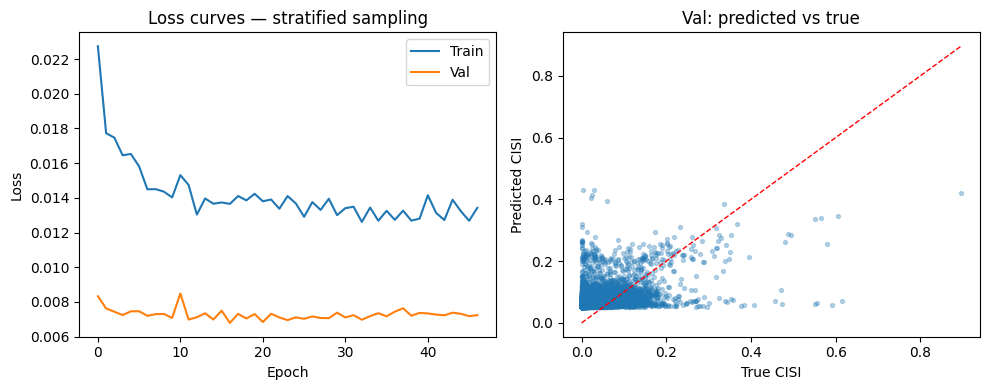

In [19]:
# Loss curves
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(train_losses, label='Train')
axes[0].plot(val_losses,   label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss curves — stratified sampling')
axes[0].legend()

axes[1].scatter(targets, preds, alpha=0.3, s=8)
axes[1].plot([0, targets.max()], [0, targets.max()], 'r--', lw=1)
axes[1].set_xlabel('True CISI'); axes[1].set_ylabel('Predicted CISI')
axes[1].set_title('Val: predicted vs true')

plt.tight_layout()
plt.savefig('stratified_val_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Save model
torch.save({'model_state_dict': model.state_dict(),
            'config': {'lam': LAM, 'lr': LR, 'dropout': DROPOUT, 'oversample_factor': oversample_factor}},
           'stratified_model.pt')
print('Saved stratified_model.pt')

Saved stratified_model.pt


## Oversample factor sweep (1.5 → 3.0)
Trains one model per factor, saves all results to `stratified_search_results.csv`.

In [ ]:
import csv

OVERSAMPLE_FACTORS = [1.5, 2.0, 2.5, 3.0]
LAM     = 15
LR      = 0.00089691
DROPOUT = 0.2
PROJECT = 'cisi-cnn'
GROUP   = 'stratified_oversampling'

results_path = 'stratified_search_results.csv'
fieldnames   = ['oversample_factor', 'global_r2', 'global_mae',
                'city_r2', 'city_mae', 'city_underprediction',
                'city15_r2', 'city15_mae', 'city15_underprediction', 'pred_max']

# Resume support
completed_factors = set()
if os.path.exists(results_path):
    with open(results_path, 'r') as f:
        for row in csv.DictReader(f):
            completed_factors.add(float(row['oversample_factor']))
    print(f'Resuming — already done: {sorted(completed_factors)}')
else:
    with open(results_path, 'w', newline='') as f:
        csv.DictWriter(f, fieldnames=fieldnames).writeheader()

for factor in OVERSAMPLE_FACTORS:
    if factor in completed_factors:
        print(f'Skipping factor={factor} (already done)')
        continue

    print(f'\n=== oversample_factor={factor} ===')

    sw = np.where(train_cisi_vals > 0.15, float(factor), 1.0)
    sampler_s = WeightedRandomSampler(torch.FloatTensor(sw), len(sw), replacement=True)
    loader_s  = DataLoader(train_dataset, batch_size=32, sampler=sampler_s, drop_last=True)

    m    = CNN({'dropout': DROPOUT}).to(device)
    crit = WeightedMSELoss(threshold=0.2, factor=LAM)
    opt  = torch.optim.Adam(m.parameters(), lr=LR)
    sch  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=50, eta_min=1e-6)
    es   = EarlyStopping(patience=30, delta=0.0001)

    run = wandb.init(
        project=PROJECT,
        group=GROUP,
        config={'oversample_factor': factor, 'lam': LAM, 'lr': LR, 'dropout': DROPOUT},
        reinit=True,
        name=f'oversampling_x{factor}',
    )

    for epoch in range(200):
        m.train()
        train_loss = 0.0
        for inputs, targets, _ in loader_s:
            inputs, targets = inputs.to(device), targets.to(device)
            opt.zero_grad()
            loss = crit(m(inputs), targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()
            train_loss += loss.item()
        sch.step()

        m.eval()
        val_losses = []
        with torch.no_grad():
            for inputs, targets, _ in val_loader:
                val_losses.append(crit(m(inputs.to(device)), targets.to(device)).item())
        avg_val = np.mean(val_losses)
        wandb.log({'epoch': epoch + 1,
                   'train_loss': train_loss / len(loader_s),
                   'val_loss': avg_val})
        es(avg_val)
        if es.early_stop:
            print(f'  Early stop at epoch {epoch+1}')
            break

    m.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for inputs, targets, _ in val_loader:
            all_preds.append(m(inputs.to(device)).cpu().numpy())
            all_targets.append(targets.numpy())

    preds   = np.concatenate(all_preds).flatten()
    targets = np.concatenate(all_targets).flatten()
    cm20 = targets > 0.20
    cm15 = targets > 0.15

    row = {
        'oversample_factor':      factor,
        'global_r2':              r2_score(targets, preds),
        'global_mae':             mean_absolute_error(targets, preds),
        'city_r2':                r2_score(targets[cm20], preds[cm20]),
        'city_mae':               mean_absolute_error(targets[cm20], preds[cm20]),
        'city_underprediction':   (1 - preds[cm20].mean() / targets[cm20].mean()) * 100,
        'city15_r2':              r2_score(targets[cm15], preds[cm15]),
        'city15_mae':             mean_absolute_error(targets[cm15], preds[cm15]),
        'city15_underprediction': (1 - preds[cm15].mean() / targets[cm15].mean()) * 100,
        'pred_max':               preds.max(),
    }

    wandb.log({k: v for k, v in row.items() if k != 'oversample_factor'})
    run.finish()

    with open(results_path, 'a', newline='') as f:
        csv.DictWriter(f, fieldnames=fieldnames).writerow(row)

    print(f'  Global R²={row["global_r2"]:.4f}  City underpr τ=0.15: {row["city15_underprediction"]:.1f}%  City R² τ=0.15: {row["city15_r2"]:.4f}')

print('\nSweep done. Results in:', results_path)